In [1]:
# **Loading the Dataset** 
from sklearn.datasets import fetch_20newsgroups
   # Load the dataset
newsgroups_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
texts = newsgroups_data.data

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize tools
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # Tokenize
    tokens = word_tokenize(text.lower())
    # Remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    # Stemming
    tokens = [ps.stem(t) for t in tokens]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

preprocessed_texts = [preprocess_text(text) for text in texts[:100]]  # Use a subset for demonstration

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nishaontivillu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nishaontivillu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nishaontivillu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
processed_text = preprocess_text(texts[0])
print(processed_text)


wonder anyon could enlighten car saw day sport car look late earli call bricklin door realli small addit front bumper separ rest bodi know anyon tellm model name engin spec year product car made histori whatev info funki look car plea


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
vectorizer = CountVectorizer(max_features=1000)

# Fit and transform the texts
X_bow = vectorizer.fit_transform(texts)

# Display the shape of the result
print(X_bow.shape)


(11314, 1000)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Fit and transform the texts
X_tfidf = tfidf_vectorizer.fit_transform(texts)

# Display the shape of the result
print(X_tfidf.shape)


(11314, 1000)


In [6]:
   # Display the first 10 features for both BoW and TF-IDF
print("BoW Features:", vectorizer.get_feature_names_out()[:10])
print("TF-IDF Features:", tfidf_vectorizer.get_feature_names_out()[:10])


BoW Features: ['00' '000' '02' '04' '0d' '0t' '10' '100' '11' '12']
TF-IDF Features: ['00' '000' '02' '04' '0d' '0t' '10' '100' '11' '12']


In [7]:
# Import required libraries
import numpy as np
from collections import Counter

# Calculate all required variables for the report
# Document lengths
original_lengths = [len(text.split()) for text in texts[:100]]
preprocessed_lengths = [len(text.split()) for text in preprocessed_texts]

# Word frequencies
all_words = ' '.join(preprocessed_texts).split()
word_freq = Counter(all_words)

# Sparsity calculations
bow_sparsity = (1 - (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))) * 100
tfidf_sparsity = (1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))) * 100

# TF-IDF feature importance
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
feature_names = tfidf_vectorizer.get_feature_names_out()
top_indices = mean_tfidf.argsort()[-10:][::-1]
top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

# Create comprehensive summary report
print("="*80)
print("TEXT PREPROCESSING AND VECTORIZATION SUMMARY REPORT")
print("="*80)
print()

print("📊 DATASET INFORMATION")
print("-" * 80)
print(f"Total documents: {len(texts)}")
print(f"Documents processed: {len(preprocessed_texts)}")
print(f"Categories: {len(newsgroups_data.target_names)}")
print(f"Category names: {', '.join(newsgroups_data.target_names[:5])}... (showing 5 of {len(newsgroups_data.target_names)})")
print()

print("📝 PREPROCESSING STATISTICS")
print("-" * 80)
print(f"Average document length (original): {np.mean(original_lengths):.2f} words")
print(f"Average document length (preprocessed): {np.mean(preprocessed_lengths):.2f} words")
print(f"Average reduction: {(1 - np.mean(preprocessed_lengths)/np.mean(original_lengths))*100:.1f}%")
print(f"Unique words after preprocessing: {len(word_freq)}")
print(f"Total words after preprocessing: {sum(word_freq.values())}")
print()

print("🔤 VECTORIZATION RESULTS")
print("-" * 80)
print(f"Bag-of-Words (BoW):")
print(f"  - Matrix shape: {X_bow.shape[0]} documents × {X_bow.shape[1]} features")
print(f"  - Sparsity: {bow_sparsity:.2f}%")
print(f"  - Non-zero elements: {X_bow.nnz:,}")
print(f"  - Memory size: {X_bow.data.nbytes / 1024:.2f} KB")
print()
print(f"TF-IDF:")
print(f"  - Matrix shape: {X_tfidf.shape[0]} documents × {X_tfidf.shape[1]} features")
print(f"  - Sparsity: {tfidf_sparsity:.2f}%")
print(f"  - Non-zero elements: {X_tfidf.nnz:,}")
print(f"  - Memory size: {X_tfidf.data.nbytes / 1024:.2f} KB")
print()

print("🏆 TOP 10 MOST FREQUENT WORDS")
print("-" * 80)
for i, (word, count) in enumerate(word_freq.most_common(10), 1):
    print(f"{i:2d}. {word:20s} - {count:5d} occurrences")
print()

print("⭐ TOP 10 FEATURES BY MEAN TF-IDF")
print("-" * 80)
for i, (feature, score) in enumerate(zip(top_features[:10], top_scores[:10]), 1):
    print(f"{i:2d}. {feature:20s} - {score:.6f}")
print()

print("="*80)
print("END OF REPORT")
print("="*80)

TEXT PREPROCESSING AND VECTORIZATION SUMMARY REPORT

📊 DATASET INFORMATION
--------------------------------------------------------------------------------
Total documents: 11314
Documents processed: 100
Categories: 20
Category names: alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware... (showing 5 of 20)

📝 PREPROCESSING STATISTICS
--------------------------------------------------------------------------------
Average document length (original): 198.20 words
Average document length (preprocessed): 98.45 words
Average reduction: 50.3%
Unique words after preprocessing: 3274
Total words after preprocessing: 9845

🔤 VECTORIZATION RESULTS
--------------------------------------------------------------------------------
Bag-of-Words (BoW):
  - Matrix shape: 11314 documents × 1000 features
  - Sparsity: 94.71%
  - Non-zero elements: 598,930
  - Memory size: 4679.14 KB

TF-IDF:
  - Matrix shape: 11314 documents × 1000 features
  - Sparsity: 94

### Word Cloud Visualizations for Top Features

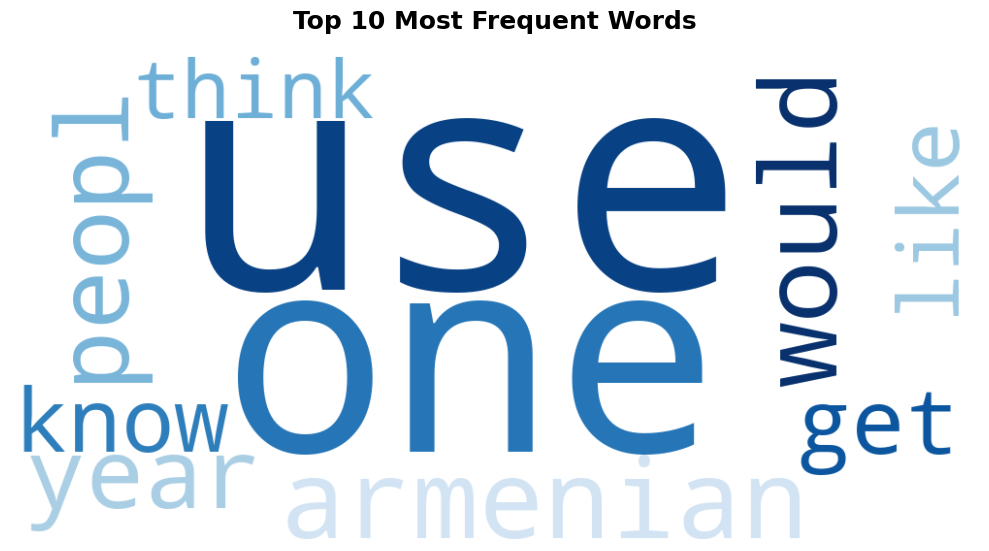

📊 Top 10 Most Frequent Words:
 1. use             -    79 occurrences
 2. one             -    60 occurrences
 3. armenian        -    58 occurrences
 4. would           -    54 occurrences
 5. peopl           -    49 occurrences
 6. year            -    46 occurrences
 7. get             -    39 occurrences
 8. know            -    37 occurrences
 9. like            -    34 occurrences
10. think           -    33 occurrences


In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word Cloud 1: Top 10 Most Frequent Words
top_10_freq = dict(word_freq.most_common(10))
wordcloud_freq = WordCloud(width=1000, height=500, 
                            background_color='white', 
                            colormap='Blues',
                            relative_scaling=0.5,
                            min_font_size=12).generate_from_frequencies(top_10_freq)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_freq, interpolation='bilinear')
plt.axis('off')
plt.title('Top 10 Most Frequent Words', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print the data used
print("📊 Top 10 Most Frequent Words:")
for i, (word, count) in enumerate(word_freq.most_common(10), 1):
    print(f"{i:2d}. {word:15s} - {count:5d} occurrences")

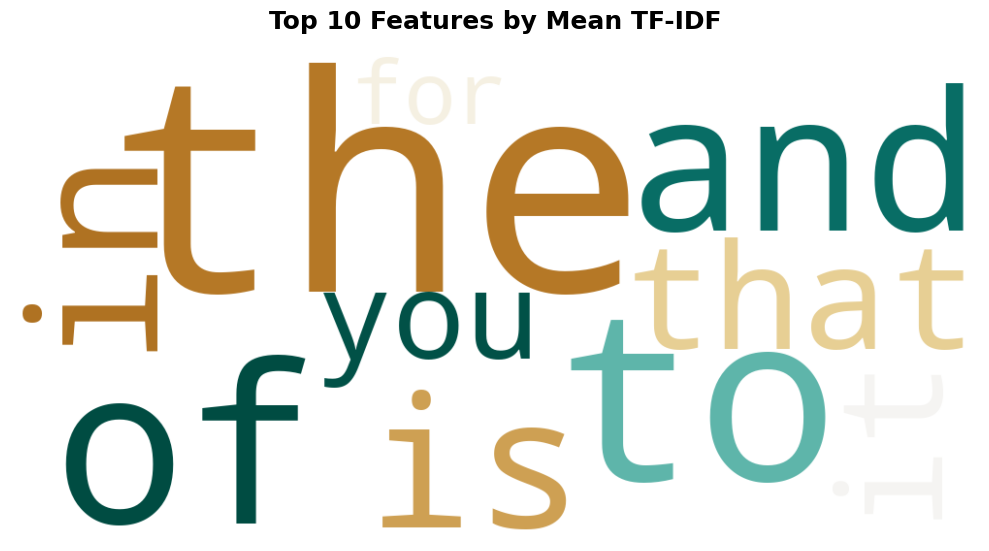

⭐ Top 10 Features by Mean TF-IDF:
 1. the             - 0.177156
 2. to              - 0.100577
 3. of              - 0.086456
 4. and             - 0.078626
 5. is              - 0.068856
 6. in              - 0.065024
 7. that            - 0.064431
 8. it              - 0.062393
 9. you             - 0.057334
10. for             - 0.051472


In [9]:
# Word Cloud 2: Top 10 Features by Mean TF-IDF
top_10_tfidf = dict(zip(top_features[:10], top_scores[:10]))
wordcloud_tfidf = WordCloud(width=1000, height=500, 
                             background_color='white', 
                             colormap='BrBG',
                             relative_scaling=0.5,
                             min_font_size=12).generate_from_frequencies(top_10_tfidf)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_tfidf, interpolation='bilinear')
plt.axis('off')
plt.title('Top 10 Features by Mean TF-IDF', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print the data used
print("⭐ Top 10 Features by Mean TF-IDF:")
for i, (feature, score) in enumerate(zip(top_features[:10], top_scores[:10]), 1):
    print(f"{i:2d}. {feature:15s} - {score:.6f}")